# Stock Return Predictor
## Notebook 1: Data Collection

**Project:** Predicting whether a stock will outperform the S&P 500 over the next month  
**Author:** Romir Kapooryes 
**Date:** April 2026  

---

### Objective
Pull and store historical price data for a universe of 20 stocks across 4 sectors 
using the `yfinance` library. This data will feed into feature engineering in the next notebook.

### Contents
1. Imports & setup
2. Define stock universe & parameters
3. Pull historical price data
4. Sanity checks & visualization
5. Save to disk

## 1. Imports and Setup

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## 2. Define Stock Universe & Parameters
20 stocks across 4 sectors: Technology, Finance, Energy, Healthcare

In [3]:
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",   # Technology
    "JPM", "GS", "BAC", "WFC", "C",            # Finance
    "XOM", "CVX", "COP", "SLB", "EOG",         # Energy
    "JNJ", "PFE", "UNH", "MRK", "ABT"          # Healthcare
]

START_DATE = "2018-01-01"
END_DATE = "2024-12-31"
DATA_DIR = "../data"

# Create data directory if it doesn't exist
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Tickers: {len(TICKERS)} stocks")
print(f"Date range: {START_DATE} to {END_DATE}")

Tickers: 20 stocks
Date range: 2018-01-01 to 2024-12-31


## 3. Pull Historical Price Data

In [8]:
# Download adjusted closing prices for all tickers via API call
raw_df = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
print(f"Raw data shape: {raw_df.shape}")
raw_df.head()




[*********************100%***********************]  20 of 20 completed


Raw data shape: (1760, 100)


Price           Close                                                         \
Ticker           AAPL        ABT       AMZN        BAC          C        COP   
Date                                                                           
2018-01-02  40.304161  50.506084  59.450500  24.637491  56.579605  42.354923   
2018-01-03  40.297153  50.617767  60.209999  24.555094  56.754597  43.135864   
2018-01-04  40.484333  50.531860  60.479500  24.876457  57.454609  43.633541   
2018-01-05  40.945255  50.677898  61.457001  24.991814  57.378548  43.549332   
2018-01-08  40.793175  50.531860  62.343498  24.818779  56.708954  43.993374   

Price                                                    ...   Volume  \
Ticker            CVX        EOG      GOOGL          GS  ...      JNJ   
Date                                                     ...            
2018-01-02  89.452370  81.049004  53.220631  213.144241  ...  6842100   
2018-01-03  90.104431  82.257683  54.128620  211.160110  ...  5350500   
2018-01-04  89.823982  82.272530  54.338886  214.111267  ...  4837600   
2018-01-05  89.676727  83.177177  55.059437  213.019226  ...  6158800   
2018-01-08  90.118469  83.577606  55.253830  209.926331  ...  5129800   

Price                                                                   \
Ticker           JPM      META       MRK      MSFT       PFE       SLB   
Date                                                                     
2018-01-02  13578800  18151900  10556504  22483800  17059833   8678200   
2018-01-03  11901000  16886600  11090460  26061400  14183151   9529200   
2018-01-04  12953700  13880900  15751650  21912000  13046517  12252300   
2018-01-05  14155000  13574500   9955057  23407100  13167517   8552700   
2018-01-08  12466500  17994700  11642546  22113000  19964341   9778900   

Price                                    
Ticker          UNH       WFC       XOM  
Date                                     
2018-01-02  3485000  13819300  11469300  
2018-01-03  2417600  14203700  13957700  
2018-01-04  2749100  18740500  10863000  
2018-01-05  2432800  14217900  11047600  
2018-01-08  2850800  15569400  10927100  

[5 rows x 100 columns]

In [9]:
# Keep only closing prices
prices_df = raw_df["Close"]
print(f"Prices shape: {prices_df.shape}")
prices_df.head()

Prices shape: (1760, 20)


Ticker,AAPL,ABT,AMZN,BAC,C,COP,CVX,EOG,GOOGL,GS,JNJ,JPM,META,MRK,MSFT,PFE,SLB,UNH,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304161,50.506084,59.450500,24.637491,56.579605,42.354923,89.452370,81.049004,53.220631,213.144241,110.764168,85.901276,180.007385,41.593510,78.870354,23.830416,54.936558,193.090469,48.653316,58.580433
2018-01-03,40.297153,50.617767,60.209999,24.555094,56.754597,43.135864,90.104431,82.257683,54.128620,211.160110,111.822273,85.988785,183.232086,41.534309,79.237404,24.006989,56.366863,195.116043,49.027637,59.730953
2018-01-04,40.484333,50.531860,60.479500,24.876457,57.454609,43.633541,89.823982,82.272530,54.338886,214.111267,111.814346,87.220627,182.894730,42.207561,79.934799,24.059315,57.765556,195.962906,49.640884,59.813629
2018-01-05,40.945255,50.677898,61.457001,24.991814,57.378548,43.549332,89.676727,83.177177,55.059437,213.019226,112.737122,86.660728,185.395142,42.163166,80.925873,24.105083,58.160679,199.699661,49.975376,59.765400
2018-01-08,40.793175,50.531860,62.343498,24.818779,56.708954,43.993374,90.118469,83.577606,55.253830,209.926331,112.880310,86.788704,186.813995,41.919025,81.008430,23.836954,59.108948,196.233521,49.409927,60.034077


## 4. Checks & Visualization

In [10]:
# Check for missing values
missing = prices_df.isnull().sum()
print(f"Missing values per ticker:\n{missing}")

Missing values per ticker:
Ticker
AAPL     0
ABT      0
AMZN     0
BAC      0
C        0
COP      0
CVX      0
EOG      0
GOOGL    0
GS       0
JNJ      0
JPM      0
META     0
MRK      0
MSFT     0
PFE      0
SLB      0
UNH      0
WFC      0
XOM      0
dtype: int64


In [13]:
# Check date range
print(f"First date: {prices_df.index.min()}")
print(f"Last date:  {prices_df.index.max()}")
print(f"Total trading days: {len(prices_df)}")

First date: 2018-01-02 00:00:00
Last date:  2024-12-30 00:00:00
Total trading days: 1760


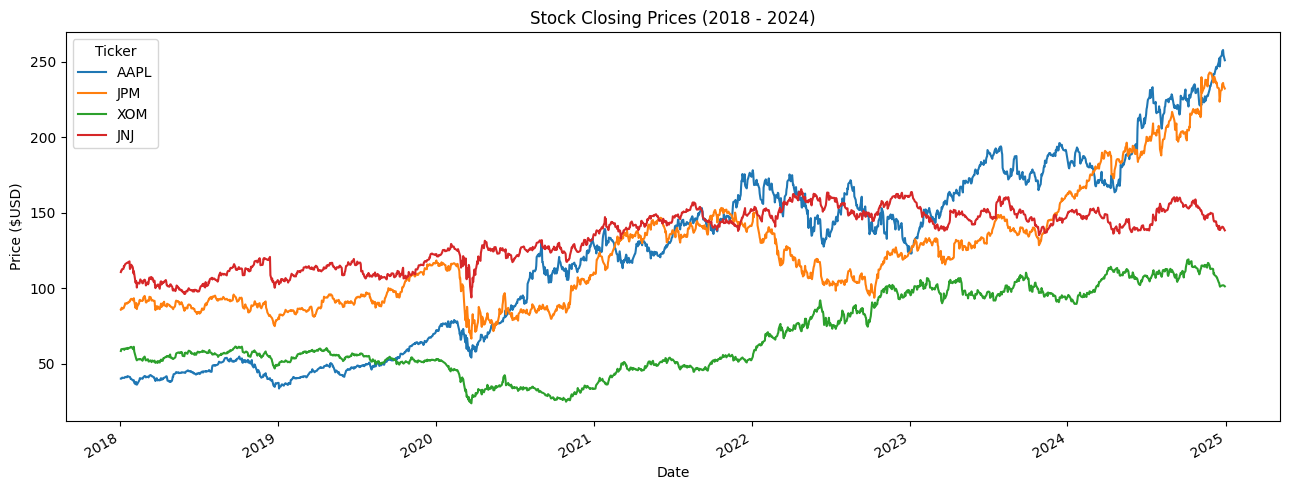

In [16]:
# Plot a sample of stocks across sectors
sample_tickers = ["AAPL", "JPM", "XOM", "JNJ"]

prices_df[sample_tickers].plot(title = "Stock Closing Prices (2018 - 2024)", figsize=(13,5))
plt.xlabel("Date")
plt.ylabel("Price ($USD)")
plt.tight_layout()
plt.show()

## 5. Save to Disk

In [17]:
# Save closing prices to CSV for use in next notebook
prices_df.to_csv(f"{DATA_DIR}/prices.csv")
print(f"Saved prices.csv — shape: {prices_df.shape}")

Saved prices.csv — shape: (1760, 20)
